Mounted at /content/drive
Google Drive mounted successfully.
trainX: (7352, 128, 9), trainy: (7352, 1), trainy_one_hot: (7352, 6)
testX: (2947, 128, 9), testy: (2947, 1), testy_one_hot: (2947, 6)

[Model Params] n_timesteps: 128, n_features: 9, n_outputs: 6
X_train shape: (5881, 128, 9), X_val shape: (1471, 128, 9)

--- CNN-LSTM Hybrid Model Summary ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,854 (468.18 KB)

 Trainable params: 119,854 (468.18 KB)

 Non-trainable params: 0 (0.00 B)


Training the model for 30 epochs with batch size 64...
Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - accuracy: 0.5157 - loss: 1.1800 - val_accuracy: 0.8396 - val_loss: 0.4180
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step - accuracy: 0.8514 - loss: 0.4065 - val_accuracy: 0.9171 - val_loss: 0.2542
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.9103 - loss: 0.2655 - val_accuracy: 0.9313 - val_loss: 0.1734
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.9367 - loss: 0.1868 - val_accuracy: 0.9334 - val_loss: 0.1594
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 134ms/step - accuracy: 0.9459 - loss: 0.1528 - val_accuracy: 0.9443 - val_loss: 0.1410
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.9448 - loss: 0.1486 - val_accuracy: 0.9504 - val_loss: 0.1209
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.9488 - loss: 0.1348 - val_accuracy: 0.9456 - val_loss: 0.1273
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s

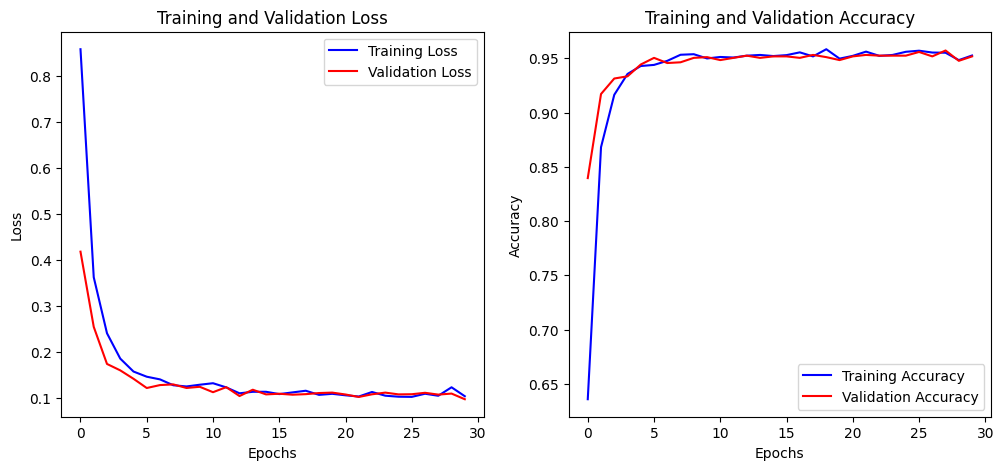

In [1]:
# -*- coding: utf-8 -*-
"""
1D_CNN_LSTM.ipynb
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, MaxPooling1D, LSTM, Flatten
from sklearn.metrics import confusion_matrix, classification_report
from numpy import argmax

def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, sep=r'\s+')
    return dataframe.values

def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    loaded = np.dstack(loaded)
    return loaded

def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    filenames = list()
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']

    X = load_group(filenames, filepath)
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y

def load_dataset(prefix=''):
    trainX, trainy = load_dataset_group('train', prefix + '/')
    testX, testy = load_dataset_group('test', prefix + '/')

    trainy = trainy - 1
    testy = testy - 1
    trainy_one_hot = to_categorical(trainy)
    testy_one_hot = to_categorical(testy)

    print(f"trainX: {trainX.shape}, trainy: {trainy.shape}, trainy_one_hot: {trainy_one_hot.shape}")
    print(f"testX: {testX.shape}, testy: {testy.shape}, testy_one_hot: {testy_one_hot.shape}")
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")

    data_path = '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset'
    trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset(data_path)

except Exception as e:
    print(f"\n[Warning] Data loading failed. Check the 'data_path' and drive mount: {e}")
    print("Using placeholder shapes for model definition.")
    trainX = np.zeros((7352, 128, 9))
    trainy_one_hot = np.zeros((7352, 6))
    testX = np.zeros((2947, 128, 9))
    testy_one_hot = np.zeros((2947, 6))
    testy = np.zeros((2947, 1))

X_train, X_val, y_train_one_hot, y_val_one_hot, y_train, y_val = train_test_split(
    trainX, trainy_one_hot, trainy, test_size=0.2, random_state=100
)

n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]
n_outputs = y_train_one_hot.shape[1]
print(f"\n[Model Params] n_timesteps: {n_timesteps}, n_features: {n_features}, n_outputs: {n_outputs}")
print(f"X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")

# ----------------------------------------------------------------------

def build_cnn_lstm_model(n_timesteps, n_features, n_outputs):

    inputs = Input(shape=(n_timesteps, n_features))

    conv1 = Conv1D(filters=64, kernel_size=5, activation='relu', padding='same')(inputs)
    pool1 = MaxPooling1D(pool_size=2)(conv1)

    conv2 = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(pool1)
    pool2 = MaxPooling1D(pool_size=2)(conv2)

    lstm = LSTM(units=100, dropout=0.3, recurrent_dropout=0.3)(pool2)

    dropout = Dropout(0.5)(lstm)

    outputs = Dense(n_outputs, activation='softmax')(dropout)

    cnn_lstm_model = Model(inputs=inputs, outputs=outputs)

    return cnn_lstm_model

cnn_lstm_model = build_cnn_lstm_model(n_timesteps, n_features, n_outputs)

cnn_lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\n--- CNN-LSTM Hybrid Model Summary ---")
cnn_lstm_model.summary()

# ----------------------------------------------------------------------

EPOCHS = 30
BATCH_SIZE = 64

print(f"\nTraining the model for {EPOCHS} epochs with batch size {BATCH_SIZE}...")
model_history = cnn_lstm_model.fit(
    x=X_train,
    y=y_train_one_hot,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_one_hot),
    verbose=1
)

print("\n--- Model Evaluation on Test Data ---")
loss, accuracy = cnn_lstm_model.evaluate(testX, testy_one_hot, batch_size=BATCH_SIZE, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

y_pred_one_hot = cnn_lstm_model.predict(testX, verbose=0)
y_pred = argmax(y_pred_one_hot, axis=1)
y_true = testy.flatten()

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_true, y_pred))

print("\n--- Classification Report (F1-score, Precision, Recall) ---")
activity_labels = ['Walking', 'Upstairs', 'Downstairs', 'Sitting', 'Standing', 'Laying']
print(classification_report(y_true, y_pred, target_names=activity_labels))

# ----------------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model_history.history['loss'], 'b', label='Training Loss')
plt.plot(model_history.history['val_loss'], 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model_history.history['accuracy'], 'b', label='Training Accuracy')
plt.plot(model_history.history['val_accuracy'], 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()